In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [17]:
# Carregando o dataset
cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [18]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [19]:
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [20]:
y = pd.Series(cancer.target)
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Length: 569, dtype: int64

In [21]:
# Dando nomes mais amigáveis às classes (0: Maligno, 1: Benigno)
y = y.map({0: 'Maligno', 1: 'Benigno'})
y

0      Maligno
1      Maligno
2      Maligno
3      Maligno
4      Maligno
        ...   
564    Maligno
565    Maligno
566    Maligno
567    Maligno
568    Benigno
Length: 569, dtype: object

In [22]:
# Vamos separar nossos dados em dois conjuntos:
# - TREINO: para ensinar o modelo (70% dos dados)
# - TESTE: para avaliar o modelo em dados que ele nunca viu (30% dos dados)
# `random_state=42` garante que a separação seja sempre a mesma, para reprodutibilidade.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
204,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,0.06373,...,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750
70,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,0.05461,...,24.86,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589
131,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,0.05796,...,19.26,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019
431,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,0.07102,...,12.88,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359
540,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,0.06782,...,12.26,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,11.63,29.29,74.87,415.1,0.09357,0.08574,0.07160,0.02017,0.1799,0.06166,...,13.12,38.81,86.04,527.8,0.1406,0.2031,0.2923,0.06835,0.2884,0.07220
400,17.91,21.02,124.40,994.0,0.12300,0.25760,0.31890,0.11980,0.2113,0.07115,...,20.80,27.78,149.60,1304.0,0.1873,0.5917,0.9034,0.19640,0.3245,0.11980
133,15.71,13.93,102.00,761.7,0.09462,0.09462,0.07135,0.05933,0.1816,0.05723,...,17.50,19.25,114.30,922.8,0.1223,0.1949,0.1709,0.13740,0.2723,0.07071
447,14.80,17.66,95.88,674.8,0.09179,0.08890,0.04069,0.02260,0.1893,0.05886,...,16.43,22.74,105.90,829.5,0.1226,0.1881,0.2060,0.08308,0.3600,0.07285


In [9]:
X_test

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
169,14.970,16.95,96.22,685.9,0.09855,0.07885,0.02602,0.03781,0.1780,0.05650,...,16.110,23.00,104.60,793.7,0.12160,0.16370,0.06648,0.08485,0.2404,0.06428
65,14.780,23.94,97.40,668.3,0.11720,0.14790,0.12670,0.09029,0.1953,0.06654,...,17.310,33.39,114.60,925.1,0.16480,0.34160,0.30240,0.16140,0.3321,0.08911
283,16.240,18.77,108.80,805.1,0.10660,0.18020,0.19480,0.09052,0.1876,0.06684,...,18.550,25.09,126.90,1031.0,0.13650,0.47060,0.50260,0.17320,0.2770,0.10630
85,18.460,18.52,121.10,1075.0,0.09874,0.10530,0.13350,0.08795,0.2132,0.06022,...,22.930,27.68,152.20,1603.0,0.13980,0.20890,0.31570,0.16420,0.3695,0.08579
242,11.300,18.19,73.93,389.4,0.09592,0.13250,0.15480,0.02854,0.2054,0.07669,...,12.580,27.96,87.16,472.9,0.13470,0.48480,0.74360,0.12180,0.3308,0.12970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


In [10]:
print(f"\nDados carregados e divididos:")
print(f" - Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f" - Tamanho do conjunto de teste: {len(X_test)} amostras")


Dados carregados e divididos:
 - Tamanho do conjunto de treino: 398 amostras
 - Tamanho do conjunto de teste: 171 amostras


In [11]:
# Criando o modelo da árvore
arvore = DecisionTreeClassifier(random_state=42)

# Treinando o modelo com os dados de TREINO
arvore.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
# Fazendo previsões nos dados de TREINO e de TESTE
pred_treino_arvore = arvore.predict(X_train)
pred_teste_arvore = arvore.predict(X_test)

In [13]:
# Avaliando a performance
acc_treino_arvore = accuracy_score(y_train, pred_treino_arvore)
acc_teste_arvore = accuracy_score(y_test, pred_teste_arvore)

In [14]:
acc_treino_arvore

1.0

In [15]:
acc_teste_arvore

0.9415204678362573

In [17]:
print(f"Acurácia no TREINO: {acc_treino_arvore:.4f} (Perfeito!)")
print(f"Acurácia no TESTE:  {acc_teste_arvore:.4f} (Bom, mas caiu bastante)")
print("\nOVERFITTING: a árvore 'decorou' os dados de treino (100% de acerto),")
print("mas sua performance caiu em dados novos (não vistos no treinamento), pois ela é muito específica.")


Acurácia no TREINO: 1.0000 (Perfeito!)
Acurácia no TESTE:  0.9415 (Bom, mas caiu bastante)

OVERFITTING: a árvore 'decorou' os dados de treino (100% de acerto),
mas sua performance caiu em dados novos (não vistos no treinamento), pois ela é muito específica.


In [18]:
# Agora, vamos treinar uma floresta com 100 árvores e comparar.

print("\n--- Treinando uma FLORESTA ALEATÓRIA ---")

# Criando o modelo da floresta (com 100 árvores)
floresta = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinando o modelo com os mesmos dados de TREINO
floresta.fit(X_train, y_train)


--- Treinando uma FLORESTA ALEATÓRIA ---


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Fazendo previsões nos dados de TREINO e de TESTE
pred_treino_floresta = floresta.predict(X_train)
pred_teste_floresta = floresta.predict(X_test)

In [20]:
# Avaliando a performance
acc_treino_floresta = accuracy_score(y_train, pred_treino_floresta)
acc_teste_floresta = accuracy_score(y_test, pred_teste_floresta)

In [21]:
print(f"Acurácia no TREINO: {acc_treino_floresta:.4f} (Ainda perfeito, mas mais robusto)")
print(f"Acurácia no TESTE:  {acc_teste_floresta:.4f} (Excelente resultado!)")
print("\nNote que a Floresta Aleatória manteve uma alta performance nos dados de teste.")
print("A combinação de várias árvores reduziu o overfitting e criou um modelo mais generalista e confiável.")


Acurácia no TREINO: 1.0000 (Ainda perfeito, mas mais robusto)
Acurácia no TESTE:  0.9591 (Excelente resultado!)

Note que a Floresta Aleatória manteve uma alta performance nos dados de teste.
A combinação de várias árvores reduziu o overfitting e criou um modelo mais generalista e confiável.


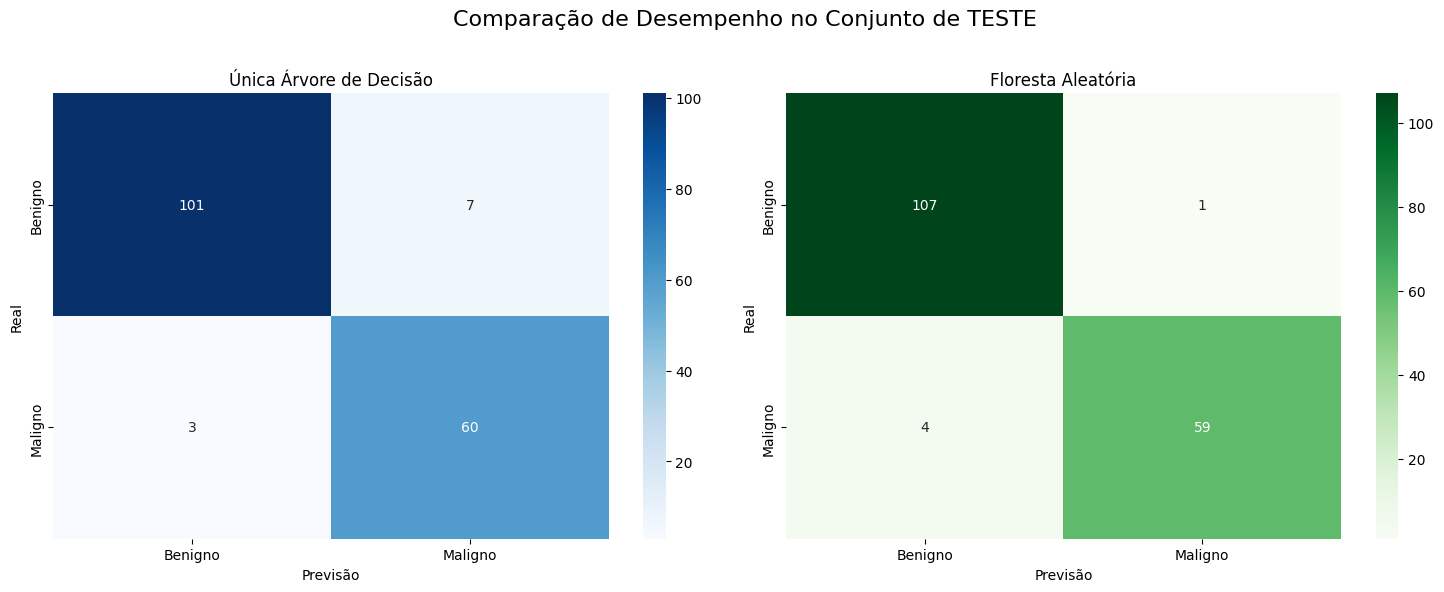

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Comparação de Desempenho no Conjunto de TESTE', fontsize=16)

# Matriz para a Árvore de Decisão
cm_arvore = confusion_matrix(y_test, pred_teste_arvore)
sns.heatmap(cm_arvore, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=floresta.classes_, yticklabels=floresta.classes_)
axes[0].set_title('Única Árvore de Decisão')
axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Real')

# Matriz para a Floresta Aleatória
cm_floresta = confusion_matrix(y_test, pred_teste_floresta)
sns.heatmap(cm_floresta, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=floresta.classes_, yticklabels=floresta.classes_)
axes[1].set_title('Floresta Aleatória')
axes[1].set_xlabel('Previsão')
axes[1].set_ylabel('Real')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [23]:
print("\nAnalisando as matrizes, podemos ver o número exato de erros e acertos.")
print(f"A Árvore Única errou {cm_arvore.sum() - cm_arvore.trace()} vezes.")
print(f"A Floresta Aleatória errou {cm_floresta.sum() - cm_floresta.trace()} vezes.")



Analisando as matrizes, podemos ver o número exato de erros e acertos.
A Árvore Única errou 10 vezes.
A Floresta Aleatória errou 5 vezes.


In [24]:
# Uma grande vantagem da Floresta Aleatória é que ela pode nos dizer quais
# características (features) foram mais importantes para a tomada de decisão.

print("\n--- Importância das Features segundo a Floresta Aleatória ---")

# Criando uma série pandas para visualizar melhor
importancias = pd.Series(data=floresta.feature_importances_, index=X.columns)
importancias


--- Importância das Features segundo a Floresta Aleatória ---


mean radius                0.032312
mean texture               0.011064
mean perimeter             0.060092
mean area                  0.053810
mean smoothness            0.006223
mean compactness           0.009216
mean concavity             0.080557
mean concave points        0.141934
mean symmetry              0.003278
mean fractal dimension     0.003140
radius error               0.016435
texture error              0.003172
perimeter error            0.011770
area error                 0.029538
smoothness error           0.005881
compactness error          0.004596
concavity error            0.005816
concave points error       0.003382
symmetry error             0.004001
fractal dimension error    0.007135
worst radius               0.077975
worst texture              0.018786
worst perimeter            0.074292
worst area                 0.118217
worst smoothness           0.011769
worst compactness          0.017539
worst concavity            0.041080
worst concave points       0

In [25]:
# Ordenando e pegando as 10 mais importantes
importancias_sorted = importancias.sort_values(ascending=False).head(10)
importancias_sorted

mean concave points     0.141934
worst concave points    0.127136
worst area              0.118217
mean concavity          0.080557
worst radius            0.077975
worst perimeter         0.074292
mean perimeter          0.060092
mean area               0.053810
worst concavity         0.041080
mean radius             0.032312
dtype: float64

/tmp/ipykernel_16962/1495854787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_sorted, y=importancias_sorted.index, palette='viridis')


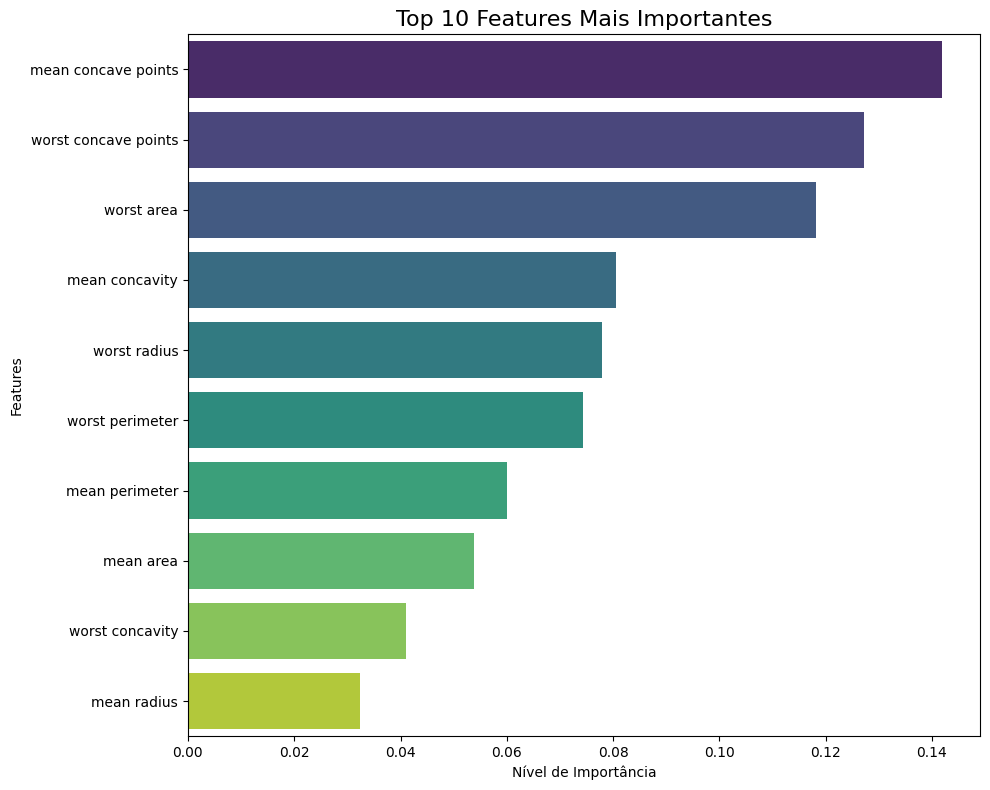

In [26]:
# Criando o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(x=importancias_sorted, y=importancias_sorted.index, palette='viridis')
plt.title('Top 10 Features Mais Importantes', fontsize=16)
plt.xlabel('Nível de Importância')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [28]:
print("\nO gráfico acima mostra quais exames/medidas o modelo mais utilizou para")
print("diferenciar um tumor maligno de um benigno. Uma informação muito valiosa!")


O gráfico acima mostra quais exames/medidas o modelo mais utilizou para
diferenciar um tumor maligno de um benigno. Uma informação muito valiosa!
